In [3]:
import sys
import argparse

sys.argv = ['script_name', '--forward_amount', '0.5']

parser = argparse.ArgumentParser()
parser.add_argument('--forward_amount', type=float, help='前进的距离')

args = parser.parse_args()

from config import config
# config['scene_dir'] = "./data/scene_datasets/replica/apartment_0/habitat/replica_stage.stage_config.json"
from env.v0d0 import Env
import torch
import pickle
import numpy as np
import habitat_sim
from habitat.utils.visualizations import maps
import random
from draw import Draw
# config['scene_dir']='./data/scene_datasets/mp3d/1LXtFkjw3qL/1LXtFkjw3qL.glb'
env = Env(config)

[21:42:59:187711]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[21:42:59:189755]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[21:42:59:189806]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/1LXtFkjw3qL/1LXtFkjw3qL.glb
[21:42:59:189849]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/1pXnuDYAj8r/1pXnuDYAj8r.glb
[21:42:59:189890]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/29hnd4uzFmX/29hnd4uzFmX.glb
[21:42:5

In [4]:
env.reset()

source_poses [array([-7.321555  ,  0.15178075,  0.39395988], dtype=float32)]
agent 0 reseting
CreateContext: Context created
agent_state.position [-0.6034366  0.072447   1.0540802]


Material for category 'picture' was not found. Using default material instead.
Material for category 'objects' was not found. Using default material instead.
Material for category 'void' was not found. Using default material instead.
Material for category 'misc' was not found. Using default material instead.


[{'camera': array([[[167, 167, 142, 255],
          [167, 167, 142, 255],
          [167, 167, 142, 255],
          ...,
          [143, 143, 124, 255],
          [143, 143, 123, 255],
          [143, 143, 123, 255]],
  
         [[167, 167, 142, 255],
          [167, 167, 142, 255],
          [167, 167, 142, 255],
          ...,
          [143, 143, 123, 255],
          [143, 143, 123, 255],
          [143, 143, 123, 255]],
  
         [[167, 167, 142, 255],
          [167, 167, 142, 255],
          [167, 167, 142, 255],
          ...,
          [143, 143, 122, 255],
          [143, 143, 122, 255],
          [143, 143, 122, 255]],
  
         ...,
  
         [[ 40,  32,  32, 255],
          [ 35,  35,  26, 255],
          [ 35,  35,  26, 255],
          ...,
          [ 77,  69,  45, 255],
          [176, 168, 151, 255],
          [ 75,  67,  48, 255]],
  
         [[ 40,  32,  32, 255],
          [ 35,  35,  26, 255],
          [ 35,  35,  26, 255],
          ...,
          [ 82,  7

In [3]:
env.get_agent_rotation()

[quaternion(1, 0, 0, 0)]

In [3]:
sim = env._sim

In [4]:
sim.pathfinder.get_bounds()

(array([-7.626046, -3.115589, -4.360964], dtype=float32),
 array([ 4.156018, 10.201534, 17.4473  ], dtype=float32))

In [5]:
map = sim.pathfinder.get_topdown_view(0.01, sim.pathfinder.get_bounds()[0][1])

In [6]:
map.shape

(2180, 1178)

In [7]:
navmesh_verts = sim.pathfinder.build_navmesh_vertices()

In [ ]:
navmesh_verts

[array([-4.6760464, -2.315589 , -3.0609636], dtype=float32),
 array([-5.076046 , -2.315589 , -3.0609636], dtype=float32),
 array([-4.876046 , -2.315589 , -2.6109638], dtype=float32),
 array([-5.076046 , -2.315589 , -3.0609636], dtype=float32),
 array([-5.076046 , -2.315589 , -2.6609638], dtype=float32),
 array([-4.876046 , -2.315589 , -2.6109638], dtype=float32),
 array([-3.0260463, -2.115589 , -4.110964 ], dtype=float32),
 array([-4.526046, -2.315589, -4.110964], dtype=float32),
 array([-4.031046 , -2.315589 , -3.4659638], dtype=float32),
 array([-4.526046, -2.315589, -4.110964], dtype=float32),
 array([-4.526046 , -2.315589 , -3.1609638], dtype=float32),
 array([-4.031046 , -2.315589 , -3.4659638], dtype=float32),
 array([-4.526046 , -2.315589 , -3.1609638], dtype=float32),
 array([-4.1760464, -2.315589 , -2.6609638], dtype=float32),
 array([-4.031046 , -2.315589 , -3.4659638], dtype=float32),
 array([-4.1760464, -2.315589 , -2.6609638], dtype=float32),
 array([-4.026046 , -2.315589 

In [9]:
navmesh_verts = sim.pathfinder.build_navmesh_vertices()
height = min(x[1] for x in navmesh_verts)

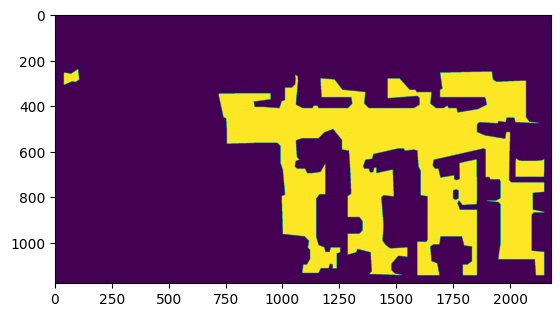

In [13]:
import matplotlib.pyplot as plt

map = topdown_map = np.rot90(sim.pathfinder.get_topdown_view(0.01,height), k=1) 
plt.imshow(map)

[22:29:44:593334]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[22:29:44:594705]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[22:29:44:595019]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[22:29:44:595033]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[22:29:44:595044]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneWireframe:coneWireframe_s

[22:29:44:596862]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[22:29:44:597487]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[22:29:44:597559]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/1LXtFkjw3qL/1LXtFkjw3qL.glb
[22:29:44:597653]:[Metadata] SceneInstanceAttributesManager.cpp(65)::setValsFromJSONDoc : No Stage specified for scene default_attributes , or specification error.
[22:29:44:597659]:[Metadata] SceneInstanceAttributesManager.cpp(105)::setValsFromJSONDoc : No Articulated Objects specified for scene default_attributes , or specification error.
[22:29:44:597664]:[Metadata] SceneInstanceAttributesManager.cpp(125)::setValsFromJS

Displaying the raw map from get_topdown_view:


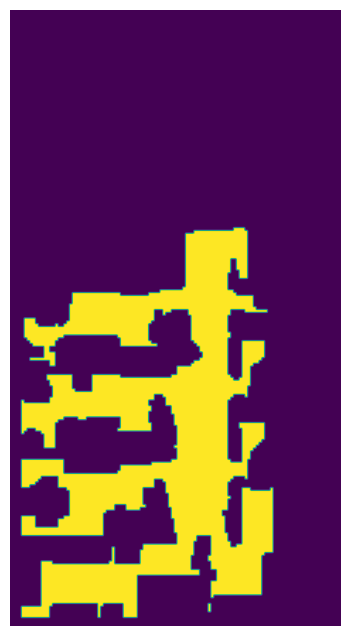

Displaying the map from the Habitat-Lab maps module:


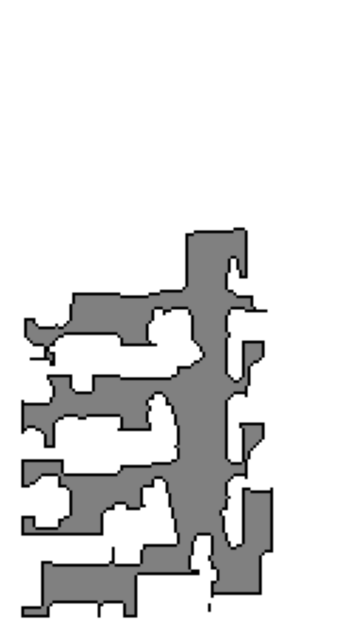

In [3]:
from draw import muti_env_draw
drawer = muti_env_draw()
drawer.show_graph(env)

In [5]:
obs = env._get_observations()

[15:28:43:615369]:[Sensor] AudioSensor.cpp(104)::setAudioListenerTransform : [Audio]  Setting the agent transform : position [ Vector(1.42964, 0.0844111, 11.5811) ], rotQuat[ Vector(1, 0, 0, 0) ]
[15:28:43:615401]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
[15:28:43:615407]:[Sensor] AudioSensor.cpp(130)::runSimulation : [Audio]  Running the audio simulator


In [6]:
len(obs)

1

In [7]:
obs[0]['camera'].shape

(128, 128, 4)

In [8]:
drawer.display_obs(env._get_observations())

AttributeError: 'muti_env_draw' object has no attribute 'display_obs'

In [10]:
import matplotlib.pyplot  as plt
from draw import Draw
import pickle
import os
output_dir = './output_images'
drawer = Draw()
# path = './data/RL/success_and_stop_data/level0'
path = './data/RL/val'
path = './data/RL/muti_env_val/B6ByNegPMKs/level0'
# file_path = [os.path.join(path , i) for i in os.listdir(path)]
file_path = os.listdir(path)
for i in range(len(file_path)):
    with open(os.path.join(path , file_path[i]), 'rb') as f:
        print(os.path.join(path , file_path[i]))
        data = pickle.load(f)
        # print(data[1]['sound_pos'])
        # sound_pose = data['sound']
        # agent_point = data['agent']
        sound_pose = [data[1]['sound_pos']]
        agent_point = data[1]['path_point']
        print(agent_point)
        image_filename = f"{output_dir}/{file_path[i]}.png"
        drawer.show_path_graph(env , sound=sound_pose ,agent=agent_point ,image_filename=image_filename)
    

FileNotFoundError: [Errno 2] No such file or directory: './data/RL/muti_env_val/B6ByNegPMKs/level0'

In [31]:
path = './data/RL/newdone/rl_episode_1.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)

In [32]:
data[0][0].keys()

dict_keys(['camera', 'audio', 'step', 'rl_pred', 'rl_logits', 'rl_value', 'reward', 'mask', 'lstm_h', 'lstm_c'])

In [33]:
data[0][0]['camera'].shape

(61, 128, 128, 4)

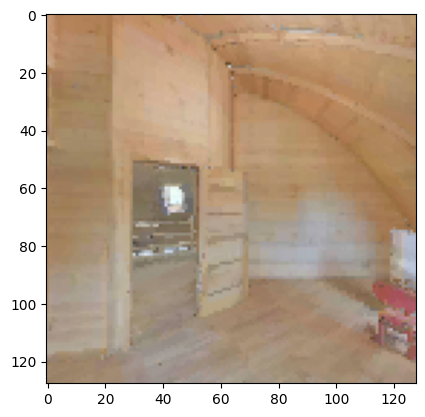

In [17]:
import matplotlib.pyplot as plt
plt.imshow(data[0][0]['camera'][6][:,: ,:3].astype(int))
plt.show()

In [ ]:
[-7.1102757,  0.072447 , -3.7348647] , [-6.1141853,  0.072447 , -2.0670211] , [-5.2036366,0.072447,-2.422783 ]

In [ ]:
a_point = np.array([[-7.1102757,  0.072447 , -3.7348647] , [-7.1102757,  0.072447 , -2.0670211] , [-5.2036366,  0.072447 , -2.0670211]])

[448.3164355847168, 448.3164355847168, 638.9803455847167]


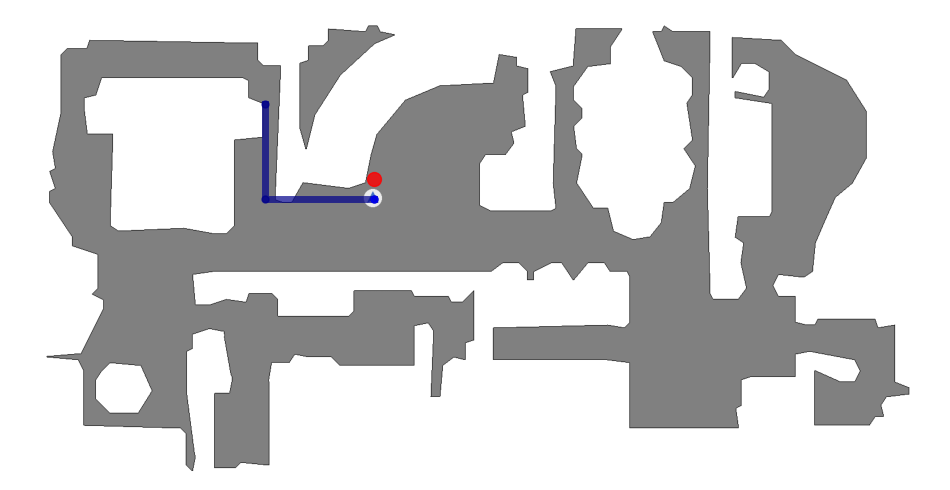

In [ ]:
drawer.show_path_graph(env , sound=np.array([[-5.2036366,0.072447,-2.422783 ]])  ,agent=a_point ,image_filename=image_filename)

In [ ]:
np.array([-5.2036366,0.072447,-2.422783 ])

array([ 1.676197 ,  0.072447 , -3.8349454])

In [ ]:
env.action_spaces[0]

AttributeError: 'MultiAudioEnv' object has no attribute 'action_spaces'

[array([ 1.676197 ,  0.072447 , -3.8349454])]
agent 0 initialization retried.
agent_state.position [-4.5250616  0.072447  -2.3857107]
[15:44:54:572587]:[Sensor] AudioSensor.cpp(86)::setAudioSourceTransform : [Audio]  Setting the audio source position :  Vector(1.6762, 0.072447, -3.83495) ]
[15:44:54:572622]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
CreateContext: Context created
[15:44:54:574639]:[Sensor] AudioSensor.cpp(104)::setAudioListenerTransform : [Audio]  Setting the agent transform : position [ Vector(-4.52506, 0.072447, -2.38571) ], rotQuat[ Vector(1, 0, 0, 0) ]
[15:44:54:574661]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
[15:44:54:574666]:[Sensor] AudioSensor.cpp(130)::runSimulation : [Audio]  Running the audio simulator
[15:44:54:574669]:[Sensor] AudioSensor.cpp(135)::runSimulation : [Audio]  New initialization, will upload geometry
[15:44:54:574672]:[Sensor] AudioSensor.cpp(139)::runSimu

Material for category 'picture' was not found. Using default material instead.
Material for category 'objects' was not found. Using default material instead.
Material for category 'void' was not found. Using default material instead.
Material for category 'misc' was not found. Using default material instead.


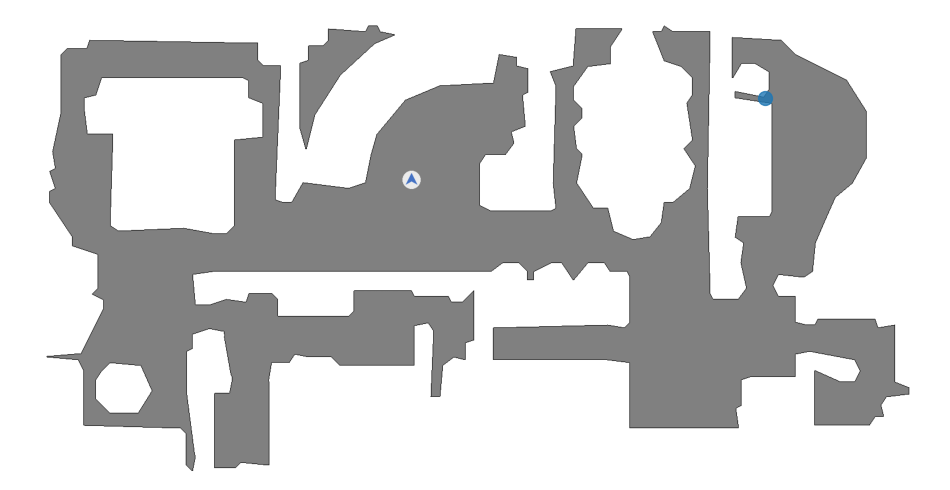

In [ ]:
drawer = Draw()
env.reset(np.array([[1.676197,0.072447,-3.8349454]]) , np.array([[-4.5250616,  0.072447 , -2.3857107]]))
drawer.show_graph(env)

In [ ]:
env.step([{
            "rl_pred": 0,
            "lstm_h": np.zeros((config["hid_dim_l"],), np.float32),
            "lstm_c": np.zeros((config["hid_dim_l"],), np.float32),
        }])
env.get_agent_pos()

agent action is 0
[15:45:09:371851]:[Sensor] AudioSensor.cpp(104)::setAudioListenerTransform : [Audio]  Setting the agent transform : position [ Vector(-4.50931, 0.072447, -3.84791) ], rotQuat[ Vector(1, 0, 0, 0) ]
[15:45:09:371883]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
[15:45:09:371889]:[Sensor] AudioSensor.cpp(130)::runSimulation : [Audio]  Running the audio simulator


[array([-4.5250616,  0.072447 , -3.3857107], dtype=float32)]

In [ ]:
a_p = list()
s_p = list()